In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/penguins.csv')

print(f"Total rows: {len(df)}")
print("\nMissing values per column:")
print(df.isna().sum())

# Identify rows missing all physical measurements
measurement_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
missing_measurements = df[df[measurement_cols].isna().all(axis=1)]
print(f"\nRows missing all measurements: {len(missing_measurements)}")

# Filter out rows missing core measurements
df_clean = df.dropna(subset=measurement_cols).copy()
print(f"Rows retained for morphological analysis: {len(df_clean)}")

Total rows: 344

Missing values per column:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Rows missing all measurements: 2
Rows retained for morphological analysis: 342


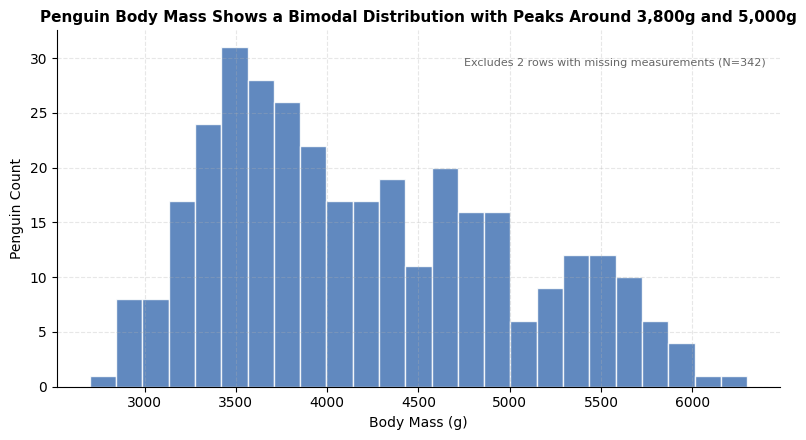

In [2]:
plt.figure(figsize=(8, 4.5))
plt.hist(df_clean['body_mass_g'], bins=25, color='#4575b4', edgecolor='white', alpha=0.85)

plt.title("Penguin Body Mass Shows a Bimodal Distribution with Peaks Around 3,800g and 5,000g", 
          fontsize=11, fontweight='bold')
plt.xlabel("Body Mass (g)")
plt.ylabel("Penguin Count")
plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().spines[['top', 'right']].set_visible(False)

# Explicitly state data cleaning decision on chart as required by rule
plt.text(0.98, 0.90, "Excludes 2 rows with missing measurements (N=342)", 
         transform=plt.gca().transAxes, ha='right', fontsize=8, color='#666666')

plt.tight_layout()
plt.show()

### Distribution Shape
The distribution is clearly **bimodal** (two distinct humps: one primary peak around 3,800g and a secondary peak around 5,000g), along with mild positive skew. A single unimodal normal distribution does not fit this data.

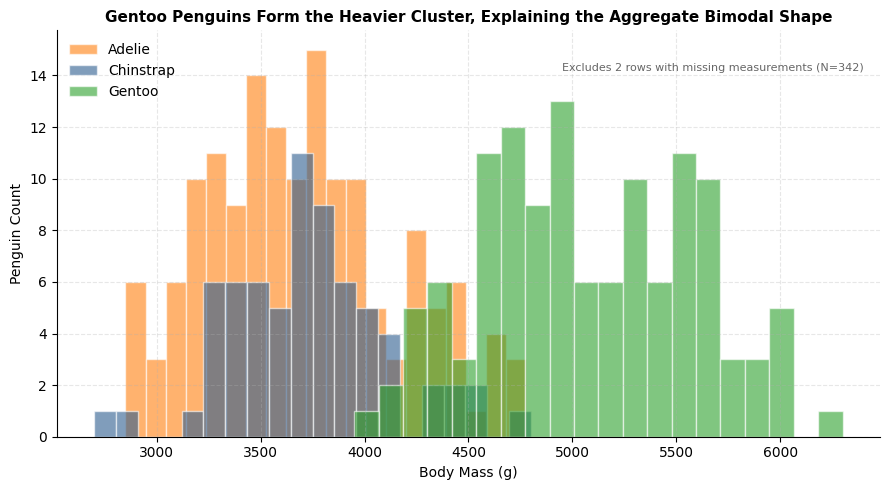

In [3]:
plt.figure(figsize=(9, 5))
species_list = ['Adelie', 'Chinstrap', 'Gentoo']
colors = {'Adelie': '#ff7f0e', 'Chinstrap': '#2b5c8f', 'Gentoo': '#2ca02c'}

for sp in species_list:
    subset = df_clean[df_clean['species'] == sp]
    plt.hist(subset['body_mass_g'], bins=20, alpha=0.6, label=sp, color=colors[sp], edgecolor='white')

plt.title("Gentoo Penguins Form the Heavier Cluster, Explaining the Aggregate Bimodal Shape", 
          fontsize=11, fontweight='bold')
plt.xlabel("Body Mass (g)")
plt.ylabel("Penguin Count")
plt.legend(frameon=False)
plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().spines[['top', 'right']].set_visible(False)

plt.text(0.98, 0.90, "Excludes 2 rows with missing measurements (N=342)", 
         transform=plt.gca().transAxes, ha='right', fontsize=8, color='#666666')

plt.tight_layout()
plt.show()

### Chart Type Justification
An **overlapping histogram grouped by species** directly answers why the first chart had two humps. Adelie and Chinstrap penguins share overlapping weight profiles (3,000g to 4,500g), while Gentoo penguins are systematically larger (4,500g to 6,000g), forming the second peak.

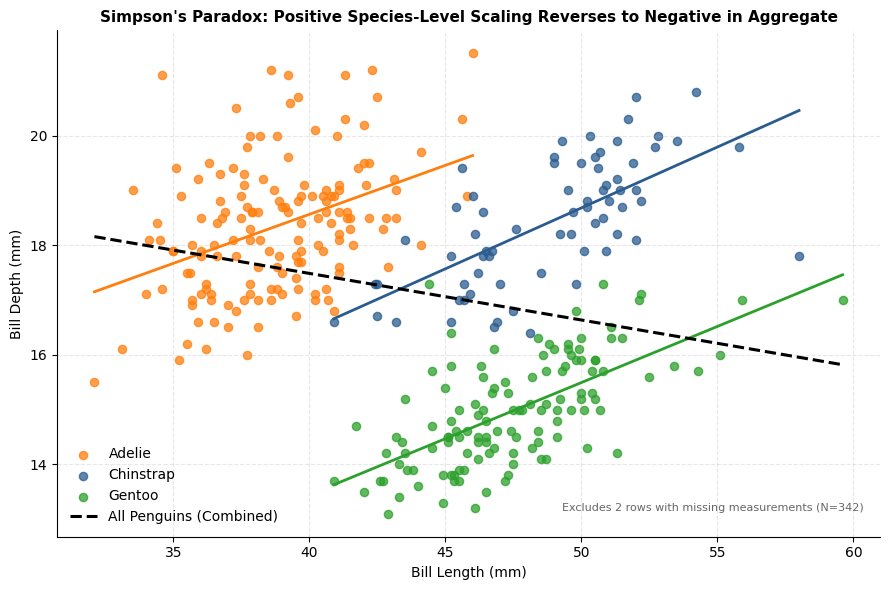

In [4]:
plt.figure(figsize=(9, 6))

# Plot species-level scatters and trendlines
for sp in species_list:
    sub = df_clean[df_clean['species'] == sp]
    plt.scatter(sub['bill_length_mm'], sub['bill_depth_mm'], color=colors[sp], label=sp, alpha=0.75, s=35)
    
    # Within-species linear trendline
    m, b = np.polyfit(sub['bill_length_mm'], sub['bill_depth_mm'], 1)
    x_vals = np.linspace(sub['bill_length_mm'].min(), sub['bill_length_mm'].max(), 50)
    plt.plot(x_vals, m * x_vals + b, color=colors[sp], lw=2)

# Aggregate trendline across all penguins
m_all, b_all = np.polyfit(df_clean['bill_length_mm'], df_clean['bill_depth_mm'], 1)
x_all = np.linspace(df_clean['bill_length_mm'].min(), df_clean['bill_length_mm'].max(), 100)
plt.plot(x_all, m_all * x_all + b_all, color='black', linestyle='--', lw=2.2, label='All Penguins (Combined)')

plt.title("Simpson's Paradox: Positive Species-Level Scaling Reverses to Negative in Aggregate", 
          fontsize=11, fontweight='bold')
plt.xlabel("Bill Length (mm)")
plt.ylabel("Bill Depth (mm)")
plt.legend(frameon=False)
plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().spines[['top', 'right']].set_visible(False)

plt.text(0.98, 0.05, "Excludes 2 rows with missing measurements (N=342)", 
         transform=plt.gca().transAxes, ha='right', fontsize=8, color='#666666')

plt.tight_layout()
plt.show()

### Explanation of Simpson's Paradox
Across all penguins combined, bill length and bill depth appear **negatively correlated** (dashed black line, $r < 0$). However, within **every individual species**, bill length and bill depth are clearly **positively correlated** ($r > 0$).

This occurs because **species acts as a confounding variable**:
- Adelie penguins have short, deep bills.
- Gentoo penguins have long, shallow bills.

When distinct subgroups with different baseline centers are aggregated, the shift between cluster means overpowers the internal positive relationship, reversing the apparent slope. This illustrates why plotting groups separately is essential.

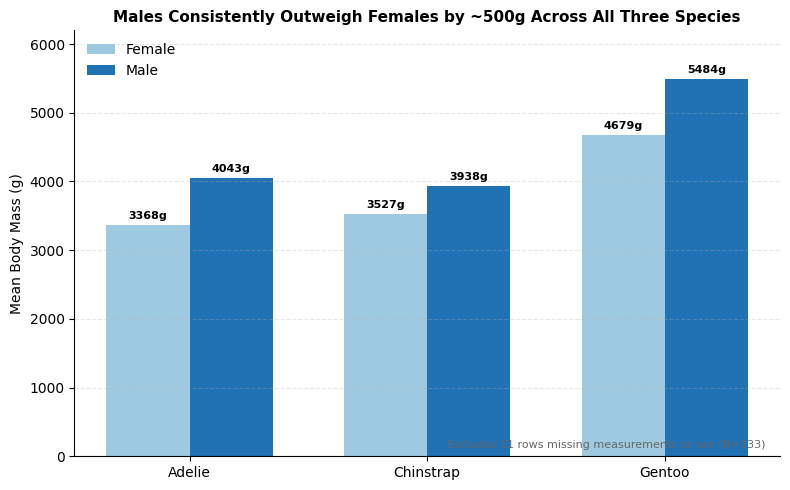

In [5]:
# Drop rows missing sex (11 additional rows)
df_sex = df_clean.dropna(subset=['sex']).copy()
dropped_total = len(df) - len(df_sex)

mean_mass = df_sex.groupby(['species', 'sex'])['body_mass_g'].mean().unstack()

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(mean_mass.index))
width = 0.35

rects1 = ax.bar(x - width/2, mean_mass['FEMALE'], width, label='Female', color='#9ecae1')
rects2 = ax.bar(x + width/2, mean_mass['MALE'], width, label='Male', color='#2171b5')

ax.set_title("Males Consistently Outweigh Females by ~500g Across All Three Species", 
             fontsize=11, fontweight='bold')
ax.set_ylabel("Mean Body Mass (g)")
ax.set_xticks(x)
ax.set_xticklabels(mean_mass.index)
ax.set_ylim(bottom=0, top=6200) # Baseline at zero
ax.legend(frameon=False)
ax.grid(True, axis='y', linestyle='--', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# Add exact direct labels on top of bars
for rect in rects1 + rects2:
    h = rect.get_height()
    ax.annotate(f'{int(h)}g',
                xy=(rect.get_x() + rect.get_width() / 2, h),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.text(0.98, 0.02, f"Excludes {dropped_total} rows missing measurements or sex (N={len(df_sex)})", 
         transform=ax.transAxes, ha='right', fontsize=8, color='#666666')

plt.tight_layout()
plt.show()

### Chart Type Justification
A **grouped bar chart with a zero baseline** allows direct visual comparison across two categorical variables (species and sex). Placing male and female bars side by side within each species makes the consistent sexual dimorphism immediately legible.